In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def research(x): 
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

In [3]:
def scale(x):
    return 7*(x/100)

In [4]:
def max_ret(per):
    inp = np.arange(0,per+1)
    net = research(inp)*scale(per-inp)
    ind = np.argmax(net)
    return ind, net[ind]
    

In [5]:
vals = [max_ret(p) for p in range(101)]
for i in range(100,-1,-1):
    print(i , vals[i][1]*0.1,vals[100-i][1]*0.9)

100 74232.99167623717 0.0
99 73268.92684927305 0.0
98 72304.86202230892 1892.4000886184685
97 71340.7971953448 3784.800177236937
96 70385.42104911036 5998.766353643332
95 69434.26671060886 8998.149530464996
94 68483.11237210738 11997.532707286664
93 67531.95803360589 15139.200708947748
92 66580.80369510439 18924.000886184684
91 65636.8905912006 22708.801063421615
90 64699.22072561203 26493.601240658558
89 63761.55086002347 30758.118527713894
88 62823.880994434876 35152.13546024445
87 61886.21112884629 39546.152392775
86 60954.82712078443 44026.0493889612
85 60031.269134105874 48917.83265440134
84 59107.711147427326 53809.615919841475
83 58184.15316074877 58701.3991852816
82 57260.595174070215 63751.664439423635
81 56342.96231173162 69064.30314270896
80 55434.20485509078 74376.94184599427
79 54525.447398449964 79689.58054927955
78 53616.68994180912 85158.00398783106
77 52707.93248516829 90835.20425368648
76 51805.46081859525 96512.40451954189
75 50912.26321827465 102189.60478539727
74 5

In [6]:
N = 10000
pnl = []
for i in range(101):
    pnl_iter = vals[100-i][1]
    frac = 0.9 - 0.8*(100-i)/101
    pnl.append(pnl_iter*frac)
pnl = np.array(pnl)
np.argmax(pnl)

np.int64(35)

Starting Evolution for N=1000, C=500...


Evolution Generations: 100%|██████████| 50/50 [02:31<00:00,  3.03s/it]


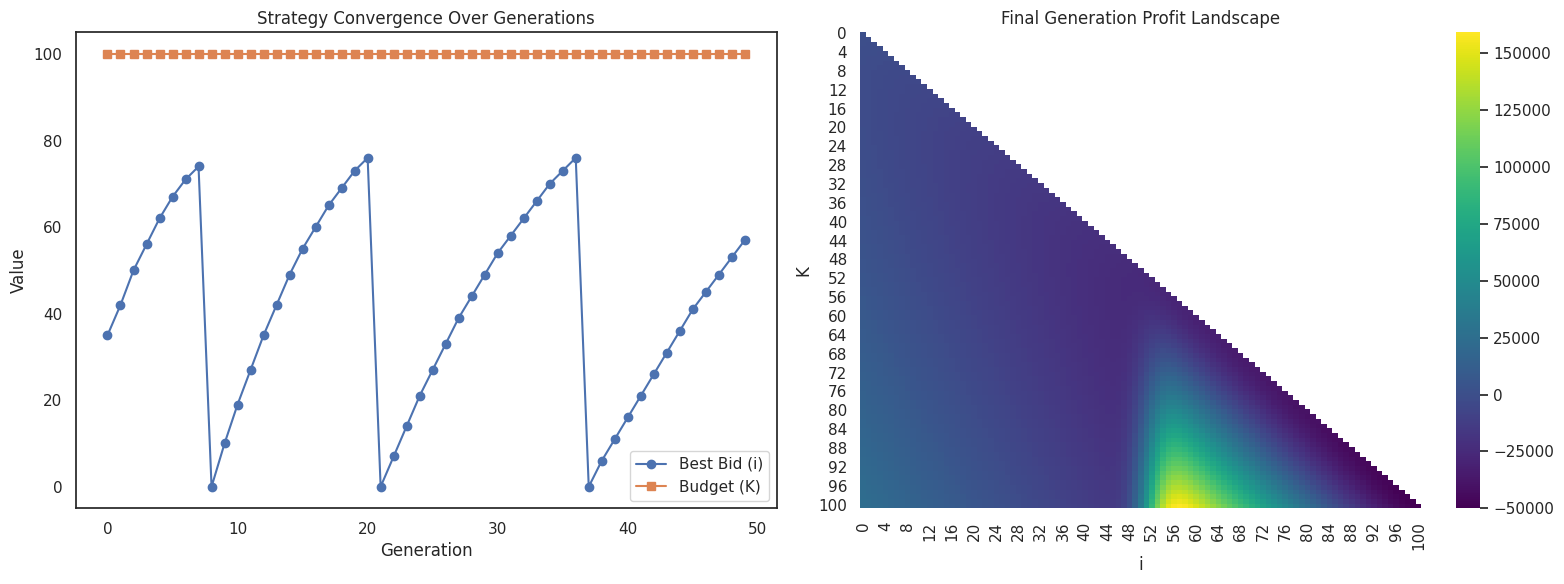

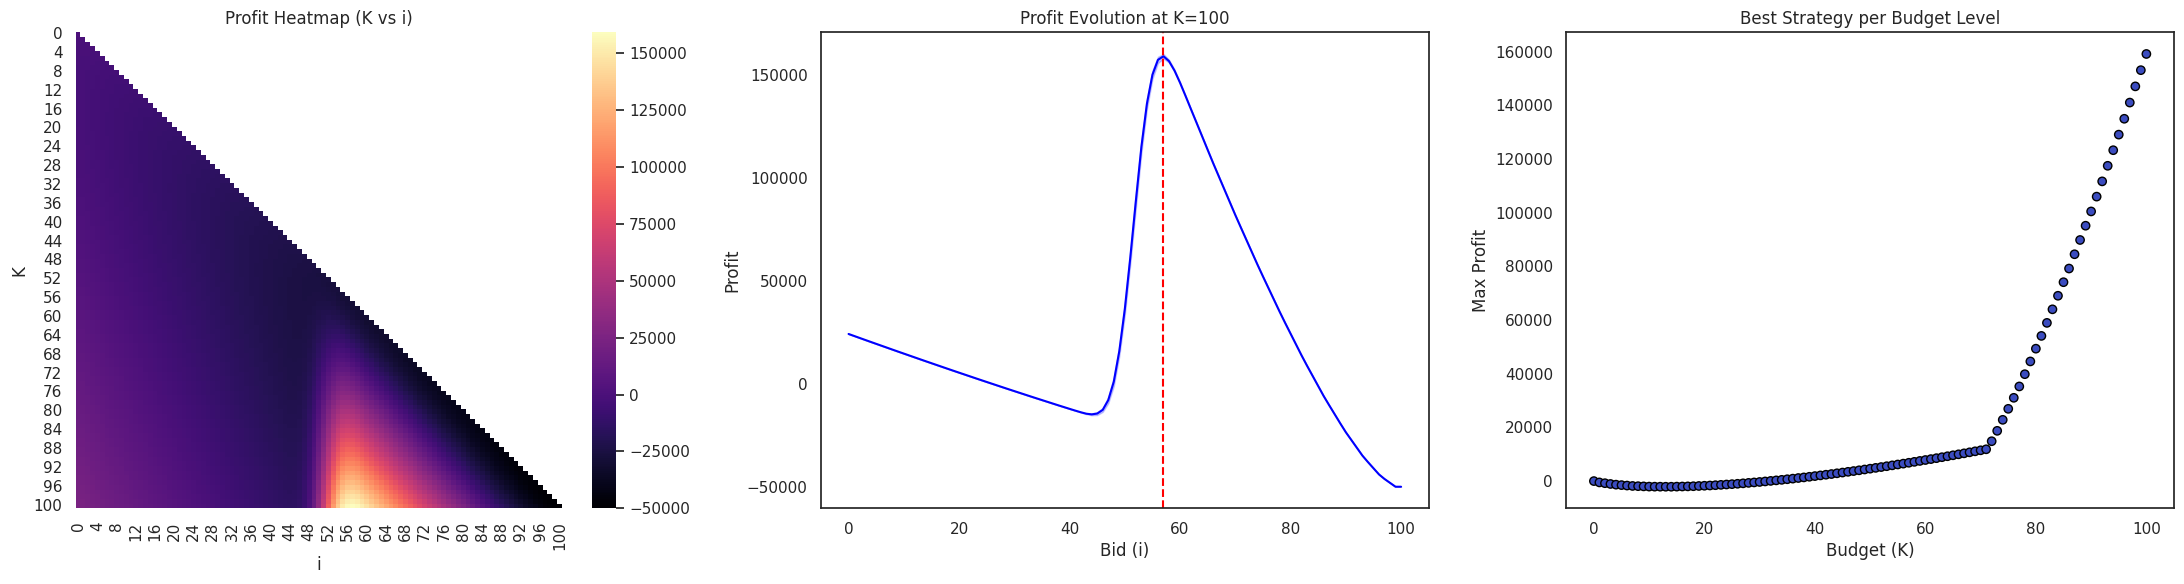

Equilibrium K: 100.0
Equilibrium i: 57.0
Expected Profit: 159166.36


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

class MarketDistributions:
    @staticmethod
    def uniform(n):
        return np.random.randint(0, 101, size=n)

    @staticmethod
    def rational(n):
        return np.clip(np.random.normal(50, 15, size=n), 0, 100).astype(int)

    @staticmethod
    def conservative(n):
        return (np.random.beta(2, 7, size=n) * 100).astype(int)

    @staticmethod
    def aggressive(n):
        return (np.random.beta(7, 2, size=n) * 100).astype(int)

    @staticmethod
    def mixed(n):
        n_agg = int(n * 0.3)
        n_con = n - n_agg
        return np.concatenate([
            np.random.beta(7, 2, n_agg) * 100,
            np.random.beta(2, 7, n_con) * 100
        ]).astype(int)

    @staticmethod
    def adaptive(n, historical_best_i, generation):
        """
        Opponents get smarter over time. They cluster around the previous winner.
        generation: increases precision (lower spread) as time goes on.
        """
        if generation == 0:
            return np.random.randint(0, 101, size=n)
        
        # Standard deviation shrinks as market matures
        std = max(20 / (generation**0.5), 2)
        bids = np.random.normal(historical_best_i, std, size=n)
        return np.clip(bids, 0, 100).astype(int)


def simulate_market(N, C, vals, dist_func, rounds=500, current_best_i=0, gen=0):
    results = []
    
    # Check if we are using the adaptive distribution which requires extra arguments
    if dist_func == MarketDistributions.adaptive:
        market_scenarios = [dist_func(N-1, current_best_i, gen) for _ in range(rounds)]
    else:
        market_scenarios = [dist_func(N-1) for _ in range(rounds)]

    for K in range(101):
        for i in range(K + 1):
            round_profits = []
            round_ranks = []
            
            for opponents in market_scenarios:
                rank = np.sum(opponents > i) + 1
                M = 0.9 - (rank - 1) * (0.8 / (N - 1))
                profit = M * vals[K-i][1] - (K * C)
                round_profits.append(profit)
                round_ranks.append(rank)
            
            results.append({
                'K': K, 
                'i': i, 
                'avg_profit': np.mean(round_profits),
                'std_dev': np.std(round_profits),
                'win_rate': np.mean([1 if r == 1 else 0 for r in round_ranks])
            })
            
    return pd.DataFrame(results)


def run_evolution(N, C, vals, generations=10):
    history = []
    current_best_i = 50 # Start with a neutral guess
    
    print(f"Starting Evolution for N={N}, C={C}...")
    
    for g in tqdm(range(generations), desc="Evolution Generations"):
        df = simulate_market(N, C, vals, MarketDistributions.adaptive, rounds=100, current_best_i=current_best_i, gen=g)
        
        best_row = df.loc[df['avg_profit'].idxmax()]
        current_best_i = best_row['i']
        current_best_K = best_row['K']
        
        history.append({
            'generation': g,
            'best_i': current_best_i,
            'best_K': current_best_K,
            'avg_profit': best_row['avg_profit']
        })
        
    return pd.DataFrame(history), df


def plot_insights(df):
    sns.set_theme(style="white")
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    pivot = df.pivot(index='K', columns='i', values='avg_profit')
    sns.heatmap(pivot, ax=axes[0], cmap='magma')
    axes[0].set_title('Profit Heatmap (K vs i)')

    best_strat = df.loc[df['avg_profit'].idxmax()]
    k_val = int(best_strat['K'])
    subset = df[df['K'] == k_val]
    axes[1].plot(subset['i'], subset['avg_profit'], color='blue')
    axes[1].fill_between(subset['i'], 
                         subset['avg_profit'] - subset['std_dev'], 
                         subset['avg_profit'] + subset['std_dev'], 
                         alpha=0.2, color='blue')
    axes[1].axvline(best_strat['i'], color='red', linestyle='--')
    axes[1].set_title(f'Profit Evolution at K={k_val}')
    axes[1].set_xlabel('Bid (i)')
    axes[1].set_ylabel('Profit')

    frontier = df.loc[df.groupby('K')['avg_profit'].idxmax()]
    axes[2].scatter(frontier['K'], frontier['avg_profit'], c=frontier['win_rate'], cmap='coolwarm', edgecolors='black')
    axes[2].set_title('Best Strategy per Budget Level')
    axes[2].set_xlabel('Budget (K)')
    axes[2].set_ylabel('Max Profit')

    plt.tight_layout()
    plt.show()


# --- Parameters Execution ---
N = 1000  # Number of participants
C = 500   # Cost multiplier
vals = [max_ret(p) for p in range(101)]

# Run the evolutionary loop
evo_history, final_df = run_evolution(N, C, vals, generations=50)

# --- Plotting Evolution Convergence ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(evo_history['generation'], evo_history['best_i'], marker='o', label='Best Bid (i)')
axes[0].plot(evo_history['generation'], evo_history['best_K'], marker='s', label='Budget (K)')
axes[0].set_title("Strategy Convergence Over Generations")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Value")
axes[0].legend()

pivot = final_df.pivot(index='K', columns='i', values='avg_profit')
sns.heatmap(pivot, ax=axes[1], cmap='viridis')
axes[1].set_title("Final Generation Profit Landscape")

plt.tight_layout()
plt.show()

# --- Plotting Deep Insights on Final Generation ---
plot_insights(final_df)

# --- Final Output Print ---
best_final = final_df.loc[final_df['avg_profit'].idxmax()]
print(f"Equilibrium K: {best_final['K']}")
print(f"Equilibrium i: {best_final['i']}")
print(f"Expected Profit: {best_final['avg_profit']:.2f}")